# Step 1 - Load and explore the dataset

In [1]:
%pip install pandas scipy scikit-learn tensorflow


error: externally-managed-environment

× This environment is externally managed
╰─> To install Python packages system-wide, try apt install
    python3-xyz, where xyz is the package you are trying to
    install.
    
    If you wish to install a non-Debian-packaged Python package,
    create a virtual environment using python3 -m venv path/to/venv.
    Then use path/to/venv/bin/python and path/to/venv/bin/pip. Make
    sure you have python3-full installed.
    
    If you wish to install a non-Debian packaged Python application,
    it may be easiest to use pipx install xyz, which will manage a
    virtual environment for you. Make sure you have pipx installed.
    
    See /usr/share/doc/python3.12/README.venv for more information.

note: If you believe this is a mistake, please contact your Python installation or OS distribution provider. You can override this, at the risk of breaking your Python installation or OS, by passing --break-system-packages.
hint: See PEP 668 for the detai

In [2]:
# Path to local dataset
path = "data"
print("Path to dataset files:", path)


Path to dataset files: data


In [3]:
import os
os.listdir(path)

['train_news.csv', '.gitkeep', 'news_dataset.csv']

In [4]:
import pandas as pd

def load_dataset(path):
    df = pd.read_csv(path)
    return df

def show_distribution(df):
    print(df['label'].value_counts())

df = load_dataset(path + "/train_news.csv")
df.head()


,Unnamed: 0,id,headline,written_by,news,label
0,0,9653,Ethics Questions Dogged Agriculture Nominee as...,Eric Lipton and Steve Eder,"WASHINGTON — In Sonny Perdue’s telling, Geo...",0
1,1,10041,U.S. Must Dig Deep to Stop Argentina’s Lionel ...,David Waldstein,HOUSTON — Venezuela had a plan. It was a ta...,0
2,2,19113,Cotton to House: ’Do Not Walk the Plank and Vo...,Pam Key,"Sunday on ABC’s “This Week,” while discussing ...",0
3,3,6868,"Paul LePage, Besieged Maine Governor, Sends Co...",Jess Bidgood,"AUGUSTA, Me. — The beleaguered Republican g...",0
4,4,7596,A Digital 9/11 If Trump Wins,Finian Cunningham,Finian Cunningham has written extensively on...,1


In [5]:
show_distribution(df)

label
1    10413
0    10387
Name: count, dtype: int64


# Step 2 - Split the dataset

In [6]:
# vectorizing before splitting lets the vectorizer learn vocabulary from the entire dataset, including the test data.
# This means the model indirectly sees information from the test set - Data Leakage. That males the evaluation unfair.
# so split dataset is step 2.


In [7]:
from sklearn.model_selection import train_test_split

df = df.dropna(subset=["news"])

X = df["news"]
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Step 3 - Vectorize

In [8]:
from sklearn.feature_extraction.text import TfidfVectorizer

def vectorize_text(train_text, test_text):
    vectorizer = TfidfVectorizer(
        stop_words='english',
        max_features=5000
    )
    X_train = vectorizer.fit_transform(train_text)
    X_test = vectorizer.transform(test_text)
    return X_train, X_test, vectorizer

X_train_vec, X_test_vec, vectorizer = vectorize_text(X_train, X_test)


# Step 4 - Build model

In [9]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input

def build_model(input_size):
    model = Sequential([
        Input(shape=(input_size,)),
        Dense(128, activation='relu'),
        Dense(64, activation='relu'),
        Dense(1, activation='sigmoid')
    ])
    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

model = build_model(X_train_vec.shape[1])
model.summary()


I0000 00:00:1773925746.227812   18918 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1773925746.228440   18918 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1773925746.275970   18918 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1773925747.597300   18918 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:0

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │       640,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 648,449 (2.47 MB)

 Trainable params: 648,449 (2.47 MB)

 Non-trainable params: 0 (0.00 B)

# Step 5 - Train Model

In [10]:
def train_model(model, X_train, y_train):
    history = model.fit(
        X_train,
        y_train,
        epochs=15,
        batch_size=32,
        validation_split=0.1
    )
    return history

history = train_model(model, X_train_vec.toarray(), y_train)


Epoch 1/15
468/468 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.9122 - loss: 0.2117 - val_accuracy: 0.9500 - val_loss: 0.1248
Epoch 2/15
468/468 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9801 - loss: 0.0589 - val_accuracy: 0.9476 - val_loss: 0.1511
Epoch 3/15
468/468 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9920 - loss: 0.0237 - val_accuracy: 0.9404 - val_loss: 0.2097
Epoch 4/15
468/468 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9983 - loss: 0.0075 - val_accuracy: 0.9458 - val_loss: 0.2215
Epoch 5/15
468/468 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9995 - loss: 0.0019 - val_accuracy: 0.9446 - val_loss: 0.2393
Epoch 6/15
468/468 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9999 - loss: 5.3071e-04 - val_accuracy: 0.9482 - val_loss: 0.2627
Epoch 7/15
468/468 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 1.0000 - loss: 1.7322e-04 - val_accuracy: 0.9476 - val_loss: 0.2781
Epoch 8/15
468/468 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 1.0000 - loss: 9.8716e-05 - val_

# Step 6 - Evaluate

In [11]:
loss, accuracy = model.evaluate(X_test_vec.toarray(), y_test)
print("Accuracy:", accuracy)


130/130 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9429 - loss: 0.4605
Accuracy: 0.9429328441619873


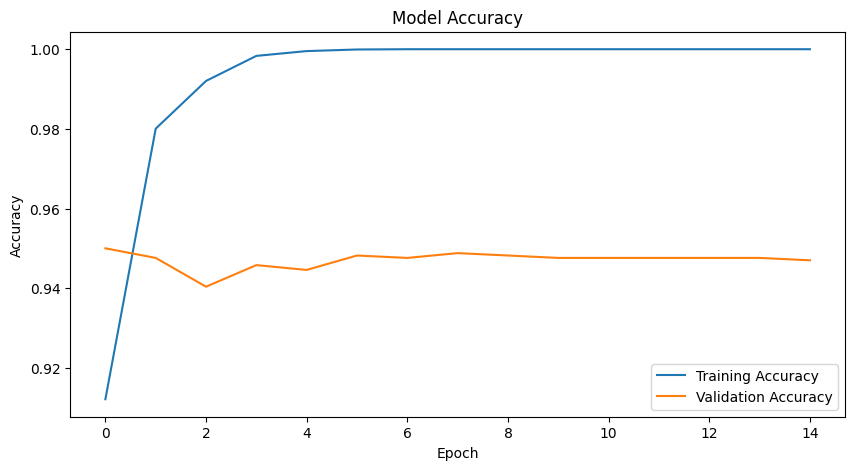

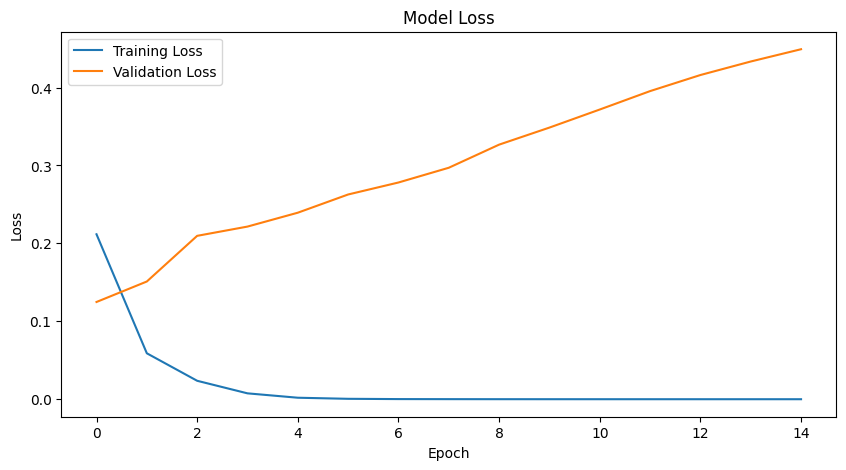

In [12]:
import matplotlib.pyplot as plt

# Plot Training and Validation Accuracy
plt.figure(figsize=(10, 5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.savefig('images/accuracy.png')
plt.show()

# Plot Training and Validation Loss
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.savefig('images/loss.png')
plt.show()


# Step 7 - Test custom headlines

In [13]:
def predict_news(model, vectorizer, text):
    text_vector = vectorizer.transform([text]).toarray()
    prediction = model.predict(text_vector)[0][0]
    if prediction > 0.5:
        return "Fake News"
    else:
        return "Real News"

headline = "Scientists confirm water on Mars discovered by Rover"
print(f"Headline: {headline} -> Prediction: {predict_news(model, vectorizer, headline)}")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
Headline: Scientists confirm water on Mars discovered by Rover -> Prediction: Fake News
